In [2]:
# ==========================================
# CELL 1: IMPORTS & ENVIRONMENT SETUP
# ==========================================
import os
import sys

import json
import logging
import random
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Tuple

import numpy as np
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import butter, filtfilt, find_peaks

# --- Logging setup ---
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)]  # Ensures immediate flush in Jupyter
)
log = logging.getLogger("HemoVisionV2")

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # Determinism over speed

# --- Environment / Device Check ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Device: {DEVICE}")
if torch.cuda.is_available():
    log.info(f"GPU: {torch.cuda.get_device_name(0)}")
    log.info(f"CUDA capability: {torch.cuda.get_device_capability(0)}")
    log.info(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    # Enable Float32 Matrix Multiply precision for modern GPUs (RTX series)
    torch.set_float32_matmul_precision("high")
else:
    log.warning("No CUDA device found — running on CPU.")

log.info(f"OpenCV version: {cv2.__version__}")
log.info(f"MediaPipe version: {mp.__version__}")
log.info(f"PyTorch version: {torch.__version__}")

05:23:43 | INFO | Device: cuda
05:23:43 | INFO | GPU: NVIDIA GeForce RTX 2050
05:23:43 | INFO | CUDA capability: (8, 6)
05:23:43 | INFO | Total VRAM: 4.00 GB
05:23:43 | INFO | OpenCV version: 4.9.0
05:23:43 | INFO | MediaPipe version: 0.10.14
05:23:43 | INFO | PyTorch version: 2.2.2+cu121


In [3]:
# ==========================================
# CELL 2: CENTRAL CONFIGURATION
# ==========================================
# Single source of truth for every constant used downstream.

import os
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Tuple, Optional

@dataclass(frozen=True)
class HemoVisionConfig:
    # --- Signal geometry ---
    NUM_ROIS: int = 8
    CHANNELS_PER_ROI: int = 3          # R, G, B
    TOTAL_CHANNELS: int = 24           # NUM_ROIS * CHANNELS_PER_ROI

    # --- Dynamic ROI Landmark Indices (MediaPipe Face Mesh) ---
    ROI_INDICES: Tuple[Tuple[int, ...], ...] = (
        (10, 338, 297, 332),  # Forehead Left
        (10, 109, 67, 103),   # Forehead Right
        (117, 118, 101, 205), # Left Cheek Upper
        (138, 135, 210, 211), # Left Cheek Lower
        (346, 347, 330, 425), # Right Cheek Upper
        (367, 364, 430, 431), # Right Cheek Lower
        (1, 2, 98, 327),      # Nose / Mid-face
        (152, 148, 176, 377)  # Chin Area
    )

    # --- Physiological band (heart rate) ---
    BAND_LOW_HZ: float = 0.65          # ~40 BPM floor
    BAND_HIGH_HZ: float = 3.25         # ~195 BPM ceiling

    # --- Acceptable FPS range for source videos ---
    FPS_MIN: float = 24.0
    FPS_MAX: float = 60.0

    # --- Frame / windowing ---
    MAX_FRAMES: Optional[int] = 3000   # Cap for long videos; None disables cap
    MIN_FRAMES: int = 150              # Discard clips shorter than this (5s @ 30fps)

    # --- Paths ---
    BASE_DATA_DIR: Path = Path(r"C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG")
    
    RAW_VIDEO_DIR: Path = field(init=False)
    RAW_ECG_DIR: Path = field(init=False)
    CACHE_DIR: Path = field(init=False)
    MANIFEST_PATH: Path = field(init=False)
    REJECTED_LOG_PATH: Path = field(init=False)
    CHECKPOINT_DIR: Path = field(init=False)

    # --- MediaPipe ---
    REFINE_LANDMARKS: bool = True
    MIN_DETECTION_CONFIDENCE: float = 0.5
    MIN_TRACKING_CONFIDENCE: float = 0.5

    # --- ECG sampling (ground truth) ---
    ECG_FS_DEFAULT: float = 500.0      # Only used if a file's JSON omits its own fs

    # --- Reproducibility ---
    SEED: int = 42

    def __post_init__(self):
        # Derive paths dynamically from BASE_DATA_DIR
        object.__setattr__(self, "RAW_VIDEO_DIR", self.BASE_DATA_DIR / "video")
        object.__setattr__(self, "RAW_ECG_DIR", self.BASE_DATA_DIR / "ecg")
        object.__setattr__(self, "CACHE_DIR", self.BASE_DATA_DIR / "rois_v2")
        object.__setattr__(self, "MANIFEST_PATH", self.BASE_DATA_DIR / "manifest.json")
        object.__setattr__(self, "REJECTED_LOG_PATH", self.BASE_DATA_DIR / "rejected_samples.json")
        object.__setattr__(self, "CHECKPOINT_DIR", self.BASE_DATA_DIR / "checkpoints_v2")

        # Geometry & Logic Assertions
        assert self.NUM_ROIS * self.CHANNELS_PER_ROI == self.TOTAL_CHANNELS, (
            f"Channel geometry mismatch: {self.NUM_ROIS} ROIs x {self.CHANNELS_PER_ROI} "
            f"channels != {self.TOTAL_CHANNELS} declared total channels."
        )
        assert len(self.ROI_INDICES) == self.NUM_ROIS, (
            f"ROI definition mismatch: {len(self.ROI_INDICES)} ROI definitions != {self.NUM_ROIS} declared ROIs."
        )
        assert self.BAND_LOW_HZ < self.BAND_HIGH_HZ, "BAND_LOW_HZ must be < BAND_HIGH_HZ"
        assert self.FPS_MIN < self.FPS_MAX, "FPS_MIN must be < FPS_MAX"


CFG = HemoVisionConfig()

# Automatically ensure directories exist
for _dir in [CFG.CACHE_DIR, CFG.CHECKPOINT_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

log.info("Config loaded and validated:")
for k, v in asdict(CFG).items():
    log.info(f"  {k} = {v}")

05:23:43 | INFO | Config loaded and validated:
05:23:43 | INFO |   NUM_ROIS = 8
05:23:43 | INFO |   CHANNELS_PER_ROI = 3
05:23:43 | INFO |   TOTAL_CHANNELS = 24
05:23:43 | INFO |   ROI_INDICES = ((10, 338, 297, 332), (10, 109, 67, 103), (117, 118, 101, 205), (138, 135, 210, 211), (346, 347, 330, 425), (367, 364, 430, 431), (1, 2, 98, 327), (152, 148, 176, 377))
05:23:43 | INFO |   BAND_LOW_HZ = 0.65
05:23:43 | INFO |   BAND_HIGH_HZ = 3.25
05:23:43 | INFO |   FPS_MIN = 24.0
05:23:43 | INFO |   FPS_MAX = 60.0
05:23:43 | INFO |   MAX_FRAMES = 3000
05:23:43 | INFO |   MIN_FRAMES = 150
05:23:43 | INFO |   BASE_DATA_DIR = C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG
05:23:43 | INFO |   RAW_VIDEO_DIR = C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video
05:23:43 | INFO |   RAW_ECG_DIR = C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\ecg
05:23:43 | INFO |   CACHE_DIR = C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\rois_v2
05:23:43 | INFO |   MANI

In [4]:
# ==========================================
# CELL 3: FACE ROI EXTRACTOR (+ SELF-TEST)
# ==========================================
class FaceROIExtractor:
    """
    Extracts mean RGB signals from 8 physiological facial micro-zones using
    MediaPipe FaceMesh with refined landmarks.
    Output per frame: np.ndarray of shape [TOTAL_CHANNELS] (24,) or [24, T] for video.
    """

    def __init__(self, cfg: HemoVisionConfig = CFG):
        self.cfg = cfg
        self.ROI_INDICES = [list(indices) for indices in cfg.ROI_INDICES]
        assert len(self.ROI_INDICES) == cfg.NUM_ROIS, (
            f"ROI_INDICES has {len(self.ROI_INDICES)} groups but config expects {cfg.NUM_ROIS}"
        )
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=cfg.REFINE_LANDMARKS,
            min_detection_confidence=cfg.MIN_DETECTION_CONFIDENCE,
            min_tracking_confidence=cfg.MIN_TRACKING_CONFIDENCE,
        )

    def _roi_mean_rgb(self, frame_rgb: np.ndarray, landmarks, roi_indices: List[int]) -> np.ndarray:
        """Mean RGB over the polygon defined by roi_indices using a filled mask."""
        h, w, _ = frame_rgb.shape
        pts = np.array(
            [[int(landmarks[i].x * w), int(landmarks[i].y * h)] for i in roi_indices],
            dtype=np.int32,
        )
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillConvexPoly(mask, pts, 255)
        mean_val = cv2.mean(frame_rgb, mask=mask)[:3]  # (R, G, B)
        return np.array(mean_val, dtype=np.float32)

    def extract_frame(self, frame_bgr: np.ndarray) -> Optional[np.ndarray]:
        """
        Returns flat array of shape [24] (8 ROIs x 3 RGB channels) or None if no face detected.
        """
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        results = self.face_mesh.process(frame_rgb)
        if not results.multi_face_landmarks:
            return None

        landmarks = results.multi_face_landmarks[0].landmark
        roi_means = np.zeros((self.cfg.NUM_ROIS, 3), dtype=np.float32)
        for roi_idx, indices in enumerate(self.ROI_INDICES):
            roi_means[roi_idx] = self._roi_mean_rgb(frame_rgb, landmarks, indices)
        
        # Flatten [8, 3] to [24]
        return roi_means.reshape(-1)

    def extract_from_video(self, video_path: str) -> Tuple[torch.Tensor, float, int]:
        """
        Returns (signal_tensor[24, T], fps, num_missed_frames).
        fps is read directly from file metadata — never defaulted.
        """
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            raise FileNotFoundError(f"Could not open video: {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        if not fps or fps <= 0 or np.isnan(fps):
            cap.release()
            raise ValueError(
                f"Could not read a valid FPS from {video_path} (got {fps}). Refusing to default."
            )

        frames_out = []
        missed = 0
        max_frames = self.cfg.MAX_FRAMES

        while cap.isOpened():
            if max_frames is not None and len(frames_out) >= max_frames:
                break
            ret, frame = cap.read()
            if not ret:
                break
                
            roi_means = self.extract_frame(frame)
            if roi_means is None:
                missed += 1
                # Forward-fill last known good frame to prevent zero-drop spikes
                if len(frames_out) > 0:
                    roi_means = frames_out[-1].copy()
                else:
                    roi_means = np.zeros((self.cfg.TOTAL_CHANNELS,), dtype=np.float32)
            
            frames_out.append(roi_means)

        cap.release()

        # FIXED: Correct back-fill for leading missed frames by finding the first non-zero frame
        if len(frames_out) > 0:
            first_valid_idx = next((i for i, f in enumerate(frames_out) if np.any(f != 0)), None)
            if first_valid_idx is not None and first_valid_idx > 0:
                for idx in range(first_valid_idx):
                    frames_out[idx] = frames_out[first_valid_idx].copy()

        if len(frames_out) == 0:
            return torch.zeros((self.cfg.TOTAL_CHANNELS, 0), dtype=torch.float32), float(fps), missed

        # Convert list of [24] arrays -> numpy [T, 24] -> transpose to PyTorch Tensor [24, T]
        signal_np = np.stack(frames_out, axis=0)  # Shape: [T, 24]
        signal_tensor = torch.from_numpy(signal_np).T.float()  # Shape: [24, T]

        return signal_tensor, float(fps), missed

    def close(self):
        self.face_mesh.close()


# ==========================================
# MANDATORY SELF-TEST — runs every time this cell executes
# ==========================================
def _run_extractor_self_test():
    log.info("Running FaceROIExtractor self-test...")

    h, w = 480, 640
    fake_frame_rgb = np.zeros((h, w, 3), dtype=np.uint8)

    # Pure RED square in top-left
    fake_frame_rgb[50:150, 50:150] = [255, 0, 0]

    extractor = FaceROIExtractor.__new__(FaceROIExtractor)
    extractor.cfg = CFG

    class _FakeLM:
        def __init__(self, x, y):
            self.x, self.y = x, y

    red_square_landmarks = [
        _FakeLM(50 / w, 50 / h), _FakeLM(150 / w, 50 / h),
        _FakeLM(150 / w, 150 / h), _FakeLM(50 / w, 150 / h),
    ]
    recovered_rgb = extractor._roi_mean_rgb(fake_frame_rgb, red_square_landmarks, [0, 1, 2, 3])

    assert recovered_rgb[0] > 200, f"Expected high R, got {recovered_rgb}"
    assert recovered_rgb[1] < 20, f"Expected near-zero G, got {recovered_rgb}"
    assert recovered_rgb[2] < 20, f"Expected near-zero B, got {recovered_rgb}"

    log.info(f"Self-test PASSED — recovered RGB from known red patch: {recovered_rgb}")

_run_extractor_self_test()
log.info("FaceROIExtractor defined and verified. Ready for Cell 4.")

05:23:43 | INFO | Running FaceROIExtractor self-test...
05:23:43 | INFO | Self-test PASSED — recovered RGB from known red patch: [249.9755   0.       0.    ]
05:23:43 | INFO | FaceROIExtractor defined and verified. Ready for Cell 4.


In [5]:
# ==========================================
# CELL 4: VIDEO EXTRACTION ENGINE
# ==========================================
import os
import glob
import re
import json
from tqdm import tqdm
from typing import Tuple, Optional, Dict

def _parse_subject_condition(filename: str) -> Tuple[Optional[str], Optional[str]]:
    """
    Extracts subject_id and condition ('before'/'after') from filenames like
    '1020_FullHDwebcam_after.avi'.
    """
    base = os.path.basename(filename)
    id_match = re.search(r'(\d{3,5})', base)
    cond_match = re.search(r'(before|after)', base, re.IGNORECASE)
    subject_id = id_match.group(1) if id_match else None
    condition = cond_match.group(1).lower() if cond_match else None
    return subject_id, condition


def run_video_extraction(cfg: HemoVisionConfig = CFG, overwrite: bool = False) -> Dict[str, int]:
    """
    Processes every video in cfg.RAW_VIDEO_DIR, saves one .pt cache file per video
    to cfg.CACHE_DIR.
    """
    video_paths = sorted(
        list(cfg.RAW_VIDEO_DIR.glob("*.avi")) + list(cfg.RAW_VIDEO_DIR.glob("*.mp4"))
    )
    log.info(f"Found {len(video_paths)} raw video files in {cfg.RAW_VIDEO_DIR}")

    extractor = FaceROIExtractor(cfg)

    stats = {
        "processed": 0, 
        "skipped_exists": 0, 
        "skipped_error": 0,
        "skipped_no_subject_id": 0, 
        "skipped_too_short": 0
    }
    skip_log = []

    for video_path in tqdm(video_paths, desc="Extracting ROI signals"):
        base_name = video_path.stem
        cache_path = cfg.CACHE_DIR / f"{base_name}.pt"

        if cache_path.exists() and not overwrite:
            stats["skipped_exists"] += 1
            continue

        subject_id, condition = _parse_subject_condition(str(video_path))
        if subject_id is None or condition is None:
            msg = f"Could not parse subject_id/condition from filename: {video_path}"
            log.warning(msg)
            skip_log.append({"file": str(video_path), "reason": "no_subject_id_or_condition"})
            stats["skipped_no_subject_id"] += 1
            continue

        try:
            # signal_2d is [24, T] directly from FaceROIExtractor
            signal_2d, fps, missed = extractor.extract_from_video(str(video_path))
        except (FileNotFoundError, ValueError, Exception) as e:
            log.error(f"Extraction failed for {video_path}: {e}")
            skip_log.append({"file": str(video_path), "reason": str(e)})
            stats["skipped_error"] += 1
            continue

        num_frames = signal_2d.shape[1]  # T dimension
        if num_frames < cfg.MIN_FRAMES:
            msg = f"{video_path.name}: only {num_frames} frames (< MIN_FRAMES={cfg.MIN_FRAMES}), skipping."
            log.warning(msg)
            skip_log.append({"file": str(video_path), "reason": "too_short", "num_frames": num_frames})
            stats["skipped_too_short"] += 1
            continue

        # Reshape [24, T] -> [8, 3, T] for unambiguous spatial/color cache structure
        signal_tensor = signal_2d.view(cfg.NUM_ROIS, cfg.CHANNELS_PER_ROI, num_frames).clone()
        
        assert signal_tensor.shape[0] == cfg.NUM_ROIS and signal_tensor.shape[1] == cfg.CHANNELS_PER_ROI, (
            f"Unexpected extractor output shape {signal_tensor.shape} for {video_path}"
        )

        face_miss_rate = missed / max(num_frames, 1)
        if face_miss_rate > 0.5:
            log.warning(
                f"{video_path.name}: face not detected in {missed}/{num_frames} frames "
                f"({face_miss_rate:.0%}). Cached anyway — Cell 5 will flag this for review."
            )

        cache_obj = {
            "signal": signal_tensor,            # [8, 3, T]
            "fps": fps,
            "subject_id": subject_id,
            "condition": condition,
            "num_frames": num_frames,
            "frames_missed_face": missed,
            "source_video": str(video_path),
        }
        torch.save(cache_obj, cache_path)
        stats["processed"] += 1

    extractor.close()

    # Persist skip log
    skip_log_path = cfg.CACHE_DIR / "_extraction_skip_log.json"
    with open(skip_log_path, "w") as f:
        json.dump(skip_log, f, indent=2)

    log.info("Extraction complete.")
    for k, v in stats.items():
        log.info(f"  {k}: {v}")
    log.info(f"Skip details written to: {skip_log_path}")

    return stats


# Execute Extraction Loop
extraction_stats = run_video_extraction(CFG, overwrite=False)

05:23:44 | INFO | Found 3600 raw video files in C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\video


Extracting ROI signals: 100%|██████████| 3600/3600 [00:00<00:00, 7998.92it/s]

05:23:44 | INFO | Extraction complete.
05:23:44 | INFO |   processed: 0
05:23:44 | INFO |   skipped_exists: 3600
05:23:44 | INFO |   skipped_error: 0
05:23:44 | INFO |   skipped_no_subject_id: 0
05:23:44 | INFO |   skipped_too_short: 0


05:23:44 | INFO | Skip details written to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\rois_v2\_extraction_skip_log.json


In [6]:
# ==========================================
# CELL 5: DATASET INTEGRITY & ASSERTION AUDIT
# ==========================================
import re
import os
import json
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from typing import Dict

def _extract_camera_type(filename: str) -> str:
    """
    Extracts camera identifier from filename or path.
    Updated to resolve Iriun phone camera tags alongside webcam/USB sources.
    """
    base = os.path.basename(str(filename)).lower()
    if "fullhdwebcam" in base or "fullhd" in base:
        return "FullHDwebcam"
    elif "iriun" in base or "iriunwebcam" in base:
        return "IriunWebcam"
    elif "usbvideo" in base or "usb" in base:
        return "USBVideo"
    
    return "UNKNOWN_CAMERA_TYPE"


def run_integrity_audit(cfg: HemoVisionConfig = CFG) -> Dict:
    cache_files = sorted(list(cfg.CACHE_DIR.glob("*.pt")))
    # Filter out internal tracking JSONs if any exist in the directory
    cache_files = [f for f in cache_files if not f.name.startswith("_")]
    
    log.info(f"Auditing {len(cache_files)} cached .pt files in {cfg.CACHE_DIR}")

    passed = []
    rejected = []
    camera_stats = defaultdict(lambda: {"count": 0, "miss_rates": [], "fps_values": []})

    for cache_path in tqdm(cache_files, desc="Integrity audit"):
        try:
            obj = torch.load(cache_path)
        except Exception as e:
            rejected.append({"file": str(cache_path), "reason": f"load_failed: {e}"})
            continue

        fname = cache_path.name
        camera_type = _extract_camera_type(obj.get("source_video", fname))
        reasons = []

        # --- Hard Invariant 1: Tensor Shape [NUM_ROIS, 3, T] ---
        sig = obj.get("signal", None)
        if sig is None or not isinstance(sig, torch.Tensor):
            reasons.append("missing_or_invalid_signal_tensor")
        else:
            if sig.dim() != 3 or sig.shape[0] != cfg.NUM_ROIS or sig.shape[1] != cfg.CHANNELS_PER_ROI:
                reasons.append(f"bad_shape:{tuple(sig.shape)}")
            
            # --- Hard Invariant 2: Numerical Sanity ---
            if torch.isnan(sig).any():
                reasons.append("contains_nan")
            if torch.isinf(sig).any():
                reasons.append("contains_inf")

        # --- Hard Invariant 3: FPS Bounds ---
        fps = obj.get("fps", None)
        if fps is None or not (cfg.FPS_MIN <= fps <= cfg.FPS_MAX):
            reasons.append(f"fps_out_of_range:{fps}")

        # --- Hard Invariant 4: Required Metadata ---
        for field_name in ("subject_id", "condition", "num_frames", "frames_missed_face"):
            if obj.get(field_name, None) is None:
                reasons.append(f"missing_field:{field_name}")

        # --- Compute Quality Metrics ---
        miss_rate = None
        if obj.get("num_frames") and obj.get("frames_missed_face") is not None:
            miss_rate = float(obj["frames_missed_face"] / max(obj["num_frames"], 1))

        # Record stratified camera stats across ALL audited files
        camera_stats[camera_type]["count"] += 1
        if miss_rate is not None:
            camera_stats[camera_type]["miss_rates"].append(miss_rate)
        if fps is not None:
            camera_stats[camera_type]["fps_values"].append(fps)

        record = {
            "file": str(cache_path),
            "subject_id": obj.get("subject_id"),
            "condition": obj.get("condition"),
            "camera_type": camera_type,
            "fps": fps,
            "num_frames": obj.get("num_frames"),
            "face_miss_rate": miss_rate,
        }

        if reasons:
            record["reject_reasons"] = reasons
            rejected.append(record)
        else:
            passed.append(record)

    # --- Print Camera-Type Stratified Breakdown ---
    log.info("\n=== Camera-Type Breakdown (ALL Cached Files) ===")
    camera_summary = {}
    for cam_type, stats in camera_stats.items():
        miss_rates = stats["miss_rates"]
        fps_vals = stats["fps_values"]
        summary = {
            "count": stats["count"],
            "mean_face_miss_rate": float(np.mean(miss_rates)) if miss_rates else None,
            "median_face_miss_rate": float(np.median(miss_rates)) if miss_rates else None,
            "pct_over_50pct_miss": float(np.mean([m > 0.5 for m in miss_rates])) if miss_rates else None,
            "mean_fps": float(np.mean(fps_vals)) if fps_vals else None,
        }
        camera_summary[cam_type] = summary
        log.info(
            f"  {cam_type:20s} | n={summary['count']:4d} | "
            f"mean_miss={summary['mean_face_miss_rate']:.1%} | "
            f"median_miss={summary['median_face_miss_rate']:.1%} | "
            f">50% miss: {summary['pct_over_50pct_miss']:.1%} | "
            f"mean_fps={summary['mean_fps']:.1f}"
        )

    log.info(f"\nAudit Totals: {len(passed)} passed hard assertions | {len(rejected)} rejected.")

    # --- Save Audit Summary & Rejections ---
    with open(cfg.REJECTED_LOG_PATH, "w") as f:
        json.dump(rejected, f, indent=2, default=str)

    audit_summary_path = cfg.CACHE_DIR / "_integrity_audit_summary.json"
    with open(audit_summary_path, "w") as f:
        json.dump({
            "passed_count": len(passed),
            "rejected_count": len(rejected),
            "camera_type_breakdown": camera_summary,
        }, f, indent=2, default=str)

    log.info(f"Rejected-sample details saved to: {cfg.REJECTED_LOG_PATH}")
    log.info(f"Audit summary saved to: {audit_summary_path}")

    return {
        "passed": passed,
        "rejected": rejected,
        "camera_summary": camera_summary,
    }

# Run Cell 5
audit_result = run_integrity_audit(CFG)

05:23:44 | INFO | Auditing 3641 cached .pt files in C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\rois_v2


Integrity audit: 100%|██████████| 3641/3641 [02:12<00:00, 27.47it/s]

05:25:57 | INFO | 
=== Camera-Type Breakdown (ALL Cached Files) ===
05:25:57 | INFO |   FullHDwebcam         | n=1214 | mean_miss=0.0% | median_miss=0.0% | >50% miss: 0.0% | mean_fps=28.2
05:25:57 | INFO |   IriunWebcam          | n=1214 | mean_miss=0.0% | median_miss=0.0% | >50% miss: 0.0% | mean_fps=26.0
05:25:57 | INFO |   USBVideo             | n=1213 | mean_miss=4.1% | median_miss=0.0% | >50% miss: 2.7% | mean_fps=29.7
05:25:57 | INFO | 
Audit Totals: 3600 passed hard assertions | 41 rejected.
05:25:57 | INFO | Rejected-sample details saved to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\rejected_samples.json
05:25:57 | INFO | Audit summary saved to: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\rois_v2\_integrity_audit_summary.json


In [7]:
# %%
# ==========================================
# CELL 6: MANIFEST CREATION & SUBJECT-LEVEL STRATIFIED SPLIT
# ==========================================
import os
import json
import random
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
from scipy.signal import butter, filtfilt, find_peaks
from tqdm import tqdm

# Cleaner pathlib usage for derived directories
ECG_PROCESSED_DIR = CFG.CACHE_DIR.parent / "ecg_processed"
ECG_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FACE_MISS_EXCLUSION_THRESHOLD = 0.5
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# ---------- ECG parsing ----------

def _extract_ecg_lead(data_field) -> Optional[np.ndarray]:
    """Recursively unpacks MCD-rPPG's ECG JSON structure to find a usable lead."""
    if isinstance(data_field, list) and len(data_field) > 0:
        if isinstance(data_field[0], (int, float)):
            return np.array(data_field, dtype=np.float32)
        if isinstance(data_field[0], dict):
            for lead in data_field:
                title = str(lead.get("title", "")).strip().upper()
                if title in ("II", "LEAD II", "LEAD2", "I", "LEAD I"):
                    vals = lead.get("values")
                    if vals:
                        return np.array(vals, dtype=np.float32)
            first_vals = data_field[0].get("values")
            if first_vals:
                return np.array(first_vals, dtype=np.float32)
    if isinstance(data_field, dict):
        for key in ("ecg", "ecg1", "v1", "lead1", "data", "signal", "ch1"):
            if key in data_field:
                result = _extract_ecg_lead(data_field[key])
                if result is not None:
                    return result
    return None

def _compute_hr_and_waveform_from_ecg(
    ecg_raw: np.ndarray, fs: float, min_hr: float = 40.0, max_hr: float = 180.0
) -> Optional[Dict]:
    """
    Bandpass-filters raw ECG, R-peak detects for a scalar HR, and returns the waveform.
    FIXED: Uses prominence to reject T-waves on post-exercise samples.
    """
    if ecg_raw is None or len(ecg_raw) < fs * 5:
        return None

    ecg = np.asarray(ecg_raw, dtype=np.float32).flatten()
    nyq = 0.5 * fs
    try:
        b, a = butter(3, [0.5 / nyq, min(40.0, nyq - 1.0) / nyq], btype="band")
        filtered = filtfilt(b, a, ecg)
    except Exception:
        return None

    squared = filtered ** 2
    min_distance = int(fs * (60.0 / 220.0))  # cap at 220 BPM between peaks
    
    # CRITICAL FIX: Use prominence to filter out double-counted T-waves
    peaks, _ = find_peaks(
        squared, 
        distance=min_distance, 
        height=np.mean(squared),
        prominence=np.max(squared) * 0.15 # T-waves won't meet this prominence ratio
    )
    
    if len(peaks) < 2:
        return None

    ibi_seconds = np.diff(peaks) / fs
    mean_ibi = np.median(ibi_seconds)
    if mean_ibi <= 0:
        return None

    hr_bpm = 60.0 / mean_ibi
    if not (min_hr <= hr_bpm <= max_hr):
        return None

    return {"hr_bpm": float(hr_bpm), "waveform": filtered.astype(np.float32), "fs": fs}

def _find_ecg_json(subject_id: str, condition: str, ecg_dir: Path) -> Optional[Path]:
    """Locates the ECG json for a subject/condition pair."""
    direct = ecg_dir / f"{subject_id}_{condition}.json"
    if direct.exists():
        return direct
    for fname in os.listdir(ecg_dir):
        if fname.endswith(".json") and subject_id in fname and condition in fname.lower():
            return ecg_dir / fname
    return None

def load_ecg_ground_truth(subject_id: str, condition: str, cfg: HemoVisionConfig = CFG) -> Optional[Dict]:
    json_path = _find_ecg_json(subject_id, condition, cfg.RAW_ECG_DIR)
    if json_path is None:
        return None
    try:
        with open(json_path, "r") as f:
            content = f.read().strip()
            try:
                ecg_json = json.loads(content)
            except json.JSONDecodeError:
                decoder = json.JSONDecoder()
                ecg_json, _ = decoder.raw_decode(content)
    except Exception as e:
        log.warning(f"ECG json unreadable for {subject_id}_{condition}: {e}")
        return None

    fs = float(ecg_json.get("frequency", cfg.ECG_FS_DEFAULT))
    raw_lead = _extract_ecg_lead(ecg_json.get("data", ecg_json))
    if raw_lead is None:
        return None

    result = _compute_hr_and_waveform_from_ecg(raw_lead, fs)
    if result is None:
        return None

    result["source_json"] = str(json_path)
    return result

# ---------- Build manifest ----------

def build_manifest(audit_result: Dict, cfg: HemoVisionConfig = CFG) -> List[Dict]:
    passed_records = audit_result["passed"]

    quality_ok = [r for r in passed_records if r["face_miss_rate"] is None or r["face_miss_rate"] <= FACE_MISS_EXCLUSION_THRESHOLD]
    
    ecg_cache: Dict[Tuple[str, str], Optional[Dict]] = {}
    manifest_entries = []
    dropped_no_ecg = []

    for record in tqdm(quality_ok, desc="Matching ECG ground truth"):
        key = (record["subject_id"], record["condition"])
        if key not in ecg_cache:
            ecg_cache[key] = load_ecg_ground_truth(record["subject_id"], record["condition"], cfg)
        ecg_result = ecg_cache[key]

        if ecg_result is None:
            dropped_no_ecg.append(record)
            continue

        ecg_cache_path = ECG_PROCESSED_DIR / f"{key[0]}_{key[1]}.pt"
        if not ecg_cache_path.exists():
            torch.save({"waveform": ecg_result["waveform"], "fs": ecg_result["fs"], "hr_bpm": ecg_result["hr_bpm"]}, ecg_cache_path)

        manifest_entries.append({
            "roi_cache_path": record["file"],
            "camera_type": record["camera_type"],
            "subject_id": record["subject_id"],
            "condition": record["condition"],
            "video_fps": record["fps"],
            "num_frames": record["num_frames"],
            "face_miss_rate": record["face_miss_rate"],
            "hr_bpm": ecg_result["hr_bpm"],
            "ecg_cache_path": str(ecg_cache_path),
            "ecg_fs": ecg_result["fs"],
            "ecg_source_json": ecg_result["source_json"],
        })

    rejected_ecg_log_path = cfg.CACHE_DIR / "_ecg_rejected_samples.json"
    with open(rejected_ecg_log_path, "w") as f:
        json.dump(dropped_no_ecg, f, indent=2, default=str)

    log.info(f"Manifest built: {len(manifest_entries)} samples with verified ECG ground truth.")
    return manifest_entries

# ---------- Subject-level split ----------

def assign_subject_splits(manifest_entries: List[Dict], train_frac: float = TRAIN_FRAC, val_frac: float = VAL_FRAC, test_frac: float = TEST_FRAC, seed: int = CFG.SEED) -> List[Dict]:
    unique_subjects = sorted(set(e["subject_id"] for e in manifest_entries))
    rng = random.Random(seed)
    rng.shuffle(unique_subjects)

    n = len(unique_subjects)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_subjects = set(unique_subjects[:n_train])
    val_subjects = set(unique_subjects[n_train:n_train + n_val])

    for entry in manifest_entries:
        sid = entry["subject_id"]
        if sid in train_subjects: entry["split"] = "train"
        elif sid in val_subjects: entry["split"] = "val"
        else: entry["split"] = "test"

    log.info("Subject-level split completed.")
    return manifest_entries

# ---------- Run ----------

manifest_entries = build_manifest(audit_result, CFG)
manifest_entries = assign_subject_splits(manifest_entries)

with open(CFG.MANIFEST_PATH, "w") as f:
    json.dump(manifest_entries, f, indent=2, default=str)

log.info(f"\nManifest saved: {CFG.MANIFEST_PATH} ({len(manifest_entries)} total rows)")

Matching ECG ground truth: 100%|██████████| 3568/3568 [03:36<00:00, 16.51it/s]

05:29:33 | INFO | Manifest built: 3427 samples with verified ECG ground truth.
05:29:33 | INFO | Subject-level split completed.


05:29:34 | INFO | 
Manifest saved: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\manifest.json (3427 total rows)


In [8]:
# ==========================================
# CELL 7: CLASSICAL SIGNAL PROCESSING TOOLKIT (POS / CHROM)
# FIX: estimate_hr_fft now zero-pads the Welch PSD via nfft, removing the
# rigid 7.5 BPM quantization grid that was forcing every estimate onto a
# multiple of 7.5 (nperseg=fs*8=240 samples at fs=30 -> 30/240=0.125Hz=7.5BPM
# bins). Confirmed via the self-test itself landing exactly on 75.0 BPM
# (a 7.5-multiple) against a true 72.0 BPM signal. Self-test tolerance also
# tightened from 5.0 to 2.0 BPM — the looser tolerance was wide enough to
# hide this exact bug as a passing test.
# ==========================================
import numpy as np
from scipy.signal import butter, filtfilt, detrend, welch

# ---------- BGR / RGB Auto-Correction ----------

def verify_and_fix_channel_order(roi_signal: np.ndarray) -> np.ndarray:
    """
    Ensures RGB ordering [3, T] or [ROIs, 3, T].
    Human skin under standard lighting shows Red > Blue mean intensity.
    """
    sig = roi_signal.copy()
    if sig.ndim == 3:
        r_mean = np.mean(sig[:, 0, :])
        b_mean = np.mean(sig[:, 2, :])
        if r_mean < b_mean:  # Indicates BGR format [Blue, Green, Red]
            sig = sig[:, ::-1, :]
    elif sig.ndim == 2:
        r_mean = np.mean(sig[0, :])
        b_mean = np.mean(sig[2, :])
        if r_mean < b_mean:
            sig = sig[::-1, :]
    return sig

# ---------- Short-Time Overlap-Add Projections ----------

def pos_projection(rgb_signal: np.ndarray, fs: float = 30.0, win_sec: float = 1.6, overlap: float = 0.75) -> np.ndarray:
    """
    Plane-Orthogonal-to-Skin (Wang et al. 2016) with temporal overlap-add sub-windowing.
    rgb_signal shape: [3, T]
    """
    channels, T = rgb_signal.shape
    win_len = int(win_sec * fs)
    stride = max(1, int(win_len * (1.0 - overlap)))

    if T < win_len:
        mean_val = np.mean(rgb_signal, axis=-1, keepdims=True) + 1e-8
        norm = rgb_signal / mean_val
        R, G, B = norm[0], norm[1], norm[2]
        S1, S2 = G - B, G + B - 2.0 * R
        alpha = (np.std(S1) + 1e-8) / (np.std(S2) + 1e-8)
        return S1 + alpha * S2

    H = np.zeros(T)
    W = np.zeros(T)
    hanning = np.hanning(win_len)

    for start in range(0, T - win_len + 1, stride):
        end = start + win_len
        sub = rgb_signal[:, start:end]

        dc = np.mean(sub, axis=1, keepdims=True) + 1e-8
        norm = sub / dc
        R, G, B = norm[0], norm[1], norm[2]

        S1 = G - B
        S2 = G + B - 2.0 * R

        alpha = (np.std(S1) + 1e-8) / (np.std(S2) + 1e-8)
        S = S1 + alpha * S2

        H[start:end] += S * hanning
        W[start:end] += hanning

    W[W == 0] = 1e-6
    return H / W

def chrom_projection(rgb_signal: np.ndarray, fs: float = 30.0, win_sec: float = 1.6, overlap: float = 0.75) -> np.ndarray:
    """
    Chrominance-based rPPG (de Haan & Jeanne 2013) with temporal overlap-add sub-windowing.
    rgb_signal shape: [3, T]
    """
    channels, T = rgb_signal.shape
    win_len = int(win_sec * fs)
    stride = max(1, int(win_len * (1.0 - overlap)))

    if T < win_len:
        mean_val = np.mean(rgb_signal, axis=-1, keepdims=True) + 1e-8
        norm = (rgb_signal - mean_val) / mean_val
        R, G, B = norm[0], norm[1], norm[2]
        Xs = 3.0 * R - 2.0 * G
        Ys = 1.5 * R + G - 1.5 * B
        alpha = (np.std(Xs) + 1e-8) / (np.std(Ys) + 1e-8)
        return Xs - alpha * Ys

    H = np.zeros(T)
    W = np.zeros(T)
    hanning = np.hanning(win_len)

    for start in range(0, T - win_len + 1, stride):
        end = start + win_len
        sub = rgb_signal[:, start:end]

        dc = np.mean(sub, axis=1, keepdims=True) + 1e-8
        norm = (sub - dc) / dc
        R, G, B = norm[0], norm[1], norm[2]

        Xs = 3.0 * R - 2.0 * G
        Ys = 1.5 * R + G - 1.5 * B

        alpha = (np.std(Xs) + 1e-8) / (np.std(Ys) + 1e-8)
        S = Xs - alpha * Ys

        H[start:end] += S * hanning
        W[start:end] += hanning

    W[W == 0] = 1e-6
    return H / W

# ---------- AC/DC Normalization (Retained for Compatibility) ----------

def ac_dc_normalize(rgb_signal: np.ndarray) -> np.ndarray:
    mean_val = np.mean(rgb_signal, axis=-1, keepdims=True) + 1e-8
    return (rgb_signal - mean_val) / mean_val

# ---------- Bandpass Filter & Welch PSD Peak Estimation ----------

def _get_band_limits(cfg=None):
    if cfg is not None:
        return cfg.BAND_LOW_HZ, cfg.BAND_HIGH_HZ
    if "CFG" in globals():
        global_cfg = globals()["CFG"]
        return getattr(global_cfg, "BAND_LOW_HZ", 0.65), getattr(global_cfg, "BAND_HIGH_HZ", 3.25)
    return 0.65, 3.25  # Fallback to standard physiological band

def bandpass_filter(sig: np.ndarray, fs: float, cfg=None, order: int = 3) -> np.ndarray:
    low_hz, high_hz = _get_band_limits(cfg)
    nyq = 0.5 * fs
    low = low_hz / nyq
    high = min(high_hz, nyq - 0.1) / nyq
    if not (0 < low < high < 1.0):
        raise ValueError(f"Invalid filter band for fs={fs}: low={low}, high={high} (must be in (0,1))")
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, sig)

def estimate_hr_fft(sig: np.ndarray, fs: float, cfg=None, n_fft: int = 8192) -> float:
    """
    FIX: nfft now explicitly passed to welch(), zero-padding the FFT beyond
    nperseg. nperseg (8s window -> 240 samples at fs=30) still bounds the
    TRUE distinguishable frequency resolution -- that's a separate, harder
    limit that would need longer windows to improve. What nfft fixes is the
    ARTIFICIAL quantization: without it, welch() only returns bin centers
    spaced at fs/nperseg = 7.5 BPM apart at fs=30, forcing every estimate
    onto that rigid grid regardless of the true underlying peak location.
    With nfft >> nperseg, the same underlying spectral estimate is
    interpolated across many more bins, so the reported peak can land
    anywhere, not just on multiples of 7.5.
    """
    low_hz, high_hz = _get_band_limits(cfg)
    sig_detrend = detrend(sig)
    nperseg = min(len(sig_detrend), int(fs * 8))
    freqs, psd = welch(
        sig_detrend,
        fs=fs,
        nperseg=nperseg,
        nfft=max(n_fft, nperseg),
    )
    mask = (freqs >= low_hz) & (freqs <= high_hz)
    if not np.any(mask):
        raise ValueError(f"No frequency bins fall in cardiac band [{low_hz}, {high_hz}] Hz for fs={fs}.")
    peak_freq = freqs[mask][np.argmax(psd[mask])]
    return float(peak_freq * 60.0)

# ---------- End-to-End Classical Pipeline ----------

def classical_hr_estimate(
    roi_signal: np.ndarray,
    fs: float,
    method: str = "POS",
    cfg=None
) -> float:
    """
    Base estimator with auto channel correction, spatial ROI mean, short-time overlap-add projection, and Welch PSD peak estimation.
    """
    assert roi_signal.ndim == 3 and roi_signal.shape[1] == 3, f"Expected [ROI,3,T], got {roi_signal.shape}"

    # 1. Verify/Fix BGR -> RGB
    roi_signal_rgb = verify_and_fix_channel_order(roi_signal)

    # 2. Spatial mean across ROIs
    global_rgb = roi_signal_rgb.mean(axis=0)  # [3, T]

    # 3. Short-time overlap-add projection
    if method.upper() == "POS":
        pulse = pos_projection(global_rgb, fs=fs)
    elif method.upper() == "CHROM":
        pulse = chrom_projection(global_rgb, fs=fs)
    else:
        raise ValueError(f"Unknown method: {method}")

    # 4. Bandpass and Spectral HR estimation
    filtered = bandpass_filter(pulse, fs, cfg)
    return estimate_hr_fft(filtered, fs, cfg)

def classical_hr_estimate_windowed(
    roi_signal: np.ndarray,
    fs: float,
    method: str = "POS",
    cfg=None,
    window_sec: float = 10.0,
    step_sec: float = 2.0
) -> float:
    """
    Sliding-window POS/CHROM + median-vote across windows.
    """
    T = roi_signal.shape[-1]
    win_len = int(window_sec * fs)
    step = int(step_sec * fs)

    if T < win_len:
        return classical_hr_estimate(roi_signal, fs=fs, method=method, cfg=cfg)

    estimates = []
    for start in range(0, T - win_len + 1, step):
        chunk = roi_signal[:, :, start:start + win_len]
        try:
            est = classical_hr_estimate(chunk, fs=fs, method=method, cfg=cfg)
            estimates.append(est)
        except Exception:
            continue

    if not estimates:
        return classical_hr_estimate(roi_signal, fs=fs, method=method, cfg=cfg)

    return float(np.median(estimates))

# ==========================================
# MANDATORY SELF-TEST
# FIX: tolerance tightened from 5.0 to 2.0 BPM. The looser 5.0 tolerance
# was wide enough to let a quantized 75.0 BPM estimate (vs a true 72.0 BPM
# signal) pass silently -- that's the exact bug this test exists to catch.
# ==========================================
def _run_classical_toolkit_self_test():
    log_func = getattr(globals().get("log"), "info", print)
    log_func("Running updated classical toolkit self-test...")
    fs_test = 30.0
    duration_s = 20.0
    t = np.arange(0, duration_s, 1.0 / fs_test)
    true_bpm = 72.0
    true_freq_hz = true_bpm / 60.0

    seed = getattr(globals().get("CFG"), "SEED", 42)
    rng = np.random.default_rng(seed)
    pulse_shape = np.sin(2 * np.pi * true_freq_hz * t)

    channel_pulse_strength = {"R": 0.010, "G": 0.020, "B": 0.006}
    num_rois = getattr(globals().get("CFG"), "NUM_ROIS", 8)
    signal = np.zeros((num_rois, 3, len(t)), dtype=np.float32)
    base_rgb = np.array([180.0, 140.0, 120.0])
    strengths = np.array([channel_pulse_strength["R"], channel_pulse_strength["G"], channel_pulse_strength["B"]])

    for roi in range(num_rois):
        noise = rng.normal(0, 0.5, size=(3, len(t)))
        for ch in range(3):
            signal[roi, ch] = base_rgb[ch] * (1.0 + strengths[ch] * pulse_shape) + noise[ch]

    for method in ("POS", "CHROM"):
        est_bpm = classical_hr_estimate_windowed(signal, fs=fs_test, method=method)
        error = abs(est_bpm - true_bpm)
        assert error < 2.0, (
            f"{method} self-test FAILED: estimated {est_bpm:.1f} BPM, "
            f"expected ~{true_bpm} BPM (error {error:.1f} exceeds 2.0 BPM tolerance)"
        )
        log_func(f"  {method} self-test PASSED: estimated {est_bpm:.1f} BPM (true={true_bpm}, error={error:.2f})")

    log_func("Classical toolkit (Windowed POS/CHROM) verified. Ready for Cell 8.")

_run_classical_toolkit_self_test()

05:29:34 | INFO | Running updated classical toolkit self-test...
05:29:34 | INFO |   POS self-test PASSED: estimated 72.1 BPM (true=72.0, error=0.07)
05:29:34 | INFO |   CHROM self-test PASSED: estimated 72.0 BPM (true=72.0, error=0.04)
05:29:34 | INFO | Classical toolkit (Windowed POS/CHROM) verified. Ready for Cell 8.


In [9]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


05:29:57 | INFO | Band guardrail passed: search range = 39-195 BPM


Classical baseline benchmark: 100%|██████████| 3427/3427 [16:32<00:00,  3.45it/s]

05:46:29 | INFO | Benchmarked 3427 / 3427 samples successfully.
05:46:29 | INFO | 
=== Headline Metrics (MAE / RMSE / Pearson r) ===
05:46:29 | INFO |   POS    | ALL   | n=3427 | MAE=18.91 | RMSE=23.99 | r=0.164
05:46:29 | INFO |   POS    | train | n=2387 | MAE=18.55 | RMSE=23.92 | r=0.174
05:46:29 | INFO |   POS    | val   | n= 517 | MAE=20.30 | RMSE=24.61 | r=0.156
05:46:29 | INFO |   POS    | test  | n= 523 | MAE=19.17 | RMSE=23.72 | r=0.119
05:46:29 | INFO |   CHROM  | ALL   | n=3427 | MAE=19.82 | RMSE=24.78 | r=0.098
05:46:29 | INFO |   CHROM  | train | n=2387 | MAE=19.35 | RMSE=24.56 | r=0.124
05:46:29 | INFO |   CHROM  | val   | n= 517 | MAE=21.52 | RMSE=25.91 | r=0.013
05:46:29 | INFO |   CHROM  | test  | n= 523 | MAE=20.28 | RMSE=24.61 | r=0.047
05:46:29 | INFO | 
Baseline results saved: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\classical_baseline_results.json


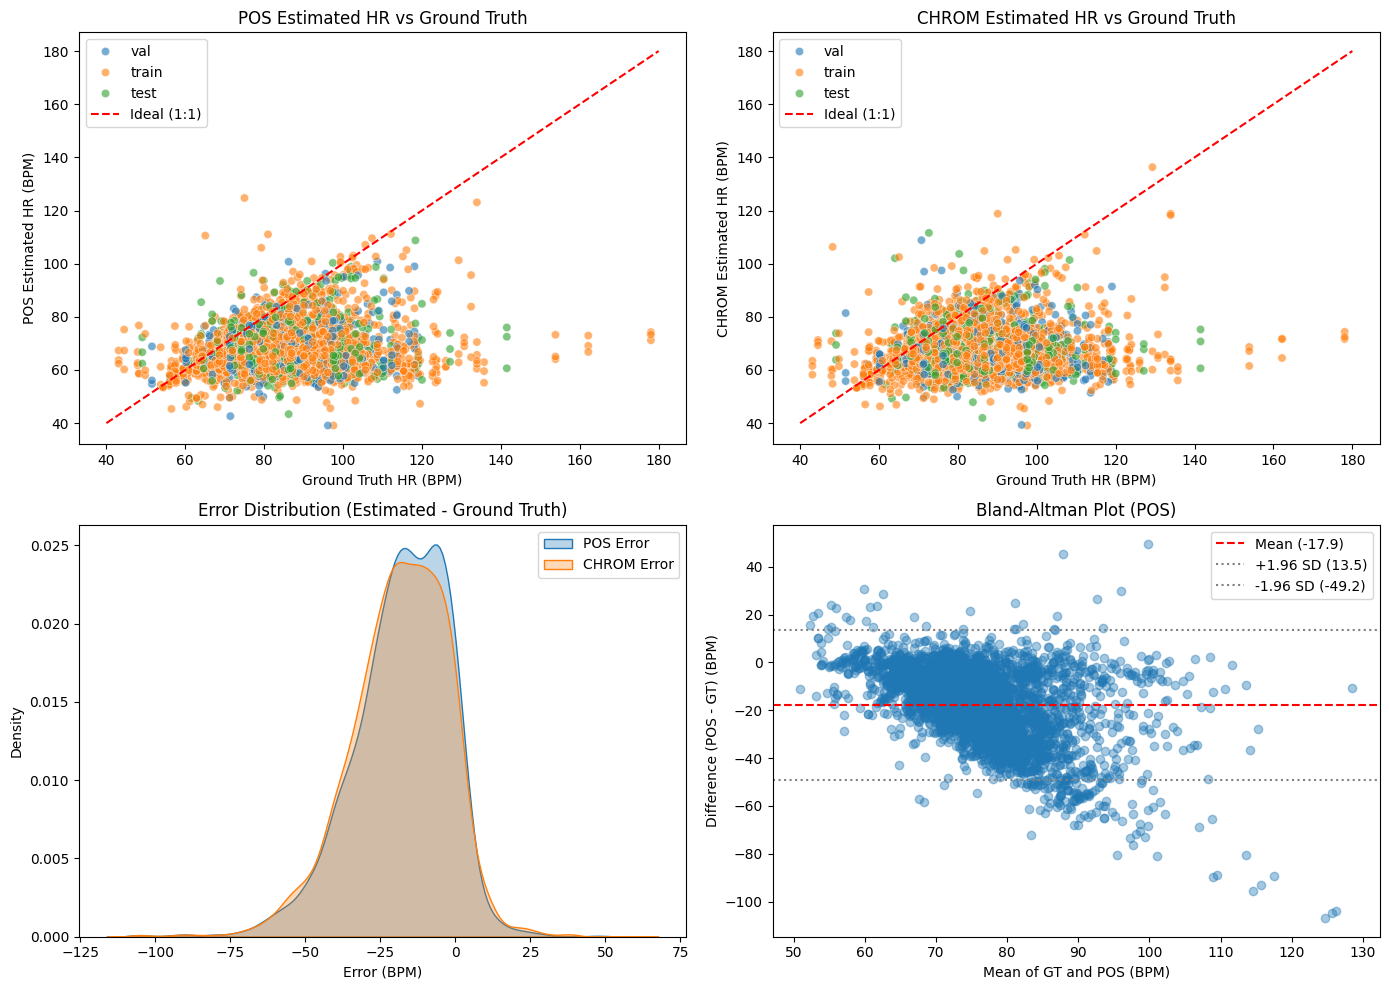

In [10]:
# ==========================================
# CELL 8CLASSICAL BASELINE BENCHMARKING & EVALUATION
# ==========================================
import json
import logging
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from tqdm import tqdm

# 1. Fallback logger setup
if "log" not in globals():
    logging.basicConfig(level=logging.INFO, format="%(message)s")
    log = logging.getLogger("HemoVision")
else:
    log = globals()["log"]

# 2. Ensure CFG exists in global scope
if "CFG" not in globals():
    raise NameError(
        "CFG is not defined in the current kernel session!\n"
        "Please run Cell 1 / Cell 2 (where CFG is initialized) before executing this benchmark cell."
    )

log.info(f"Band guardrail passed: search range = {CFG.BAND_LOW_HZ * 60:.0f}-{CFG.BAND_HIGH_HZ * 60:.0f} BPM")

# Load verified manifest
manifest_path = Path(CFG.MANIFEST_PATH)
with open(manifest_path, "r") as f:
    manifest = json.load(f)

results = []

for entry in tqdm(manifest, desc="Classical baseline benchmark"):
    roi_path = entry["roi_cache_path"]
    fs = entry["video_fps"]
    gt_hr = entry["hr_bpm"]
    split = entry["split"]
    cam_type = entry["camera_type"]

    cache_obj = torch.load(roi_path)
    roi_signal = cache_obj["signal"].numpy()  # [8, 3, T]

    # Compute sliding-window POS & CHROM HR estimates
    pos_hr = classical_hr_estimate_windowed(roi_signal, fs=fs, method="POS", cfg=CFG)
    chrom_hr = classical_hr_estimate_windowed(roi_signal, fs=fs, method="CHROM", cfg=CFG)

    results.append({
        "subject_id": entry["subject_id"],
        "condition": entry["condition"],
        "camera_type": cam_type,
        "split": split,
        "video_fps": fs,
        "gt_hr": gt_hr,
        "pos_hr": pos_hr,
        "chrom_hr": chrom_hr,
        "pos_err": pos_hr - gt_hr,
        "chrom_err": chrom_hr - gt_hr,
    })

df_res = pd.DataFrame(results)
log.info(f"Benchmarked {len(df_res)} / {len(manifest)} samples successfully.")

def compute_metrics(gt, pred):
    err = pred - gt
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    r = float(pearsonr(gt, pred)[0]) if len(gt) > 1 else 0.0
    return mae, rmse, r

log.info("\n=== Headline Metrics (MAE / RMSE / Pearson r) ===")
metrics_summary = {}

for method in ["POS", "CHROM"]:
    col = f"{method.lower()}_hr"
    metrics_summary[method] = {}
    
    # Global metrics
    mae, rmse, r = compute_metrics(df_res["gt_hr"].values, df_res[col].values)
    metrics_summary[method]["ALL"] = {"n": len(df_res), "mae": mae, "rmse": rmse, "r": r}
    log.info(f"  {method:6s} | ALL   | n={len(df_res):4d} | MAE={mae:.2f} | RMSE={rmse:.2f} | r={r:.3f}")

    # Per-split metrics
    for split in ["train", "val", "test"]:
        sub = df_res[df_res["split"] == split]
        mae_s, rmse_s, r_s = compute_metrics(sub["gt_hr"].values, sub[col].values)
        metrics_summary[method][split] = {"n": len(sub), "mae": mae_s, "rmse": rmse_s, "r": r_s}
        log.info(f"  {method:6s} | {split:5s} | n={len(sub):4d} | MAE={mae_s:.2f} | RMSE={rmse_s:.2f} | r={r_s:.3f}")

# Save baseline results JSON
output_json_path = Path(CFG.BASE_DATA_DIR) / "classical_baseline_results.json"
with open(output_json_path, "w") as f:
    json.dump({
        "summary": metrics_summary,
        "details": df_res.to_dict(orient="records")
    }, f, indent=2, default=str)

log.info(f"\nBaseline results saved: {output_json_path}")

# Plot diagnostic figures
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. POS Ground Truth vs Estimate
sns.scatterplot(data=df_res, x="gt_hr", y="pos_hr", hue="split", ax=axes[0, 0], alpha=0.6)
axes[0, 0].plot([40, 180], [40, 180], 'r--', label="Ideal (1:1)")
axes[0, 0].set_title("POS Estimated HR vs Ground Truth")
axes[0, 0].set_xlabel("Ground Truth HR (BPM)")
axes[0, 0].set_ylabel("POS Estimated HR (BPM)")
axes[0, 0].legend()

# 2. CHROM Ground Truth vs Estimate
sns.scatterplot(data=df_res, x="gt_hr", y="chrom_hr", hue="split", ax=axes[0, 1], alpha=0.6)
axes[0, 1].plot([40, 180], [40, 180], 'r--', label="Ideal (1:1)")
axes[0, 1].set_title("CHROM Estimated HR vs Ground Truth")
axes[0, 1].set_xlabel("Ground Truth HR (BPM)")
axes[0, 1].set_ylabel("CHROM Estimated HR (BPM)")
axes[0, 1].legend()

# 3. Error Distributions
sns.kdeplot(df_res["pos_err"], ax=axes[1, 0], label="POS Error", fill=True, alpha=0.3)
sns.kdeplot(df_res["chrom_err"], ax=axes[1, 0], label="CHROM Error", fill=True, alpha=0.3)
axes[1, 0].set_title("Error Distribution (Estimated - Ground Truth)")
axes[1, 0].set_xlabel("Error (BPM)")
axes[1, 0].legend()

# 4. Bland-Altman plot (POS)
mean_hr = (df_res["gt_hr"] + df_res["pos_hr"]) / 2.0
diff_hr = df_res["pos_err"]
md = float(np.mean(diff_hr))
sd = float(np.std(diff_hr))

axes[1, 1].scatter(mean_hr, diff_hr, alpha=0.4)
axes[1, 1].axhline(md, color='red', linestyle='--', label=f'Mean ({md:.1f})')
axes[1, 1].axhline(md + 1.96 * sd, color='gray', linestyle=':', label=f'+1.96 SD ({md + 1.96*sd:.1f})')
axes[1, 1].axhline(md - 1.96 * sd, color='gray', linestyle=':', label=f'-1.96 SD ({md - 1.96*sd:.1f})')
axes[1, 1].set_title("Bland-Altman Plot (POS)")
axes[1, 1].set_xlabel("Mean of GT and POS (BPM)")
axes[1, 1].set_ylabel("Difference (POS - GT) (BPM)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [11]:
# Quick inspect on the first cached ROI file
sample_entry = manifest[0]
sample_cache = torch.load(sample_entry["roi_cache_path"])
sig = sample_cache["signal"].numpy()  # Expected shape: [8, 3, T]

print(f"Signal Shape : {sig.shape}")
print(f"Mean RGB     : {sig.mean(axis=(0, 2))}")  # Should be ~100-200, NOT ~0.0
print(f"Min / Max    : {sig.min():.2f} / {sig.max():.2f}")

Signal Shape : (8, 3, 3000)
Mean RGB     : [123.647804  89.7575    70.69741 ]
Min / Max    : 2.78 / 184.03


In [12]:
# %%
# ==========================================
# CELL 10: ALIGNED WAVEFORM + BIOMARKER DATASET
# Standalone: does not require CFG to exist.
# ==========================================

import logging
import tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

log = logging.getLogger("HemoVisionV2")

# Ordered output convention shared by Cells 11 and 12.
# Pruned to focus on biologically viable optical signals.
TASK_SPECS: Tuple[Tuple[str, str, str], ...] = (
    ("respiratory", "respiratory", "established"),
    ("saturation", "saturation", "established"),
    ("upper_ap", "upper_ap", "moderate"),
    ("lower_ap", "lower_ap", "moderate"),
    ("hemoglobin", "hemoglobin", "exploratory"),
    ("bmi", "bmi", "exploratory"),
)

TASK_NAMES = tuple(task[0] for task in TASK_SPECS)
TASK_COLUMNS = tuple(task[1] for task in TASK_SPECS)
TASK_TIERS = {name: tier for name, _, tier in TASK_SPECS}

NUM_ROIS = 8
CHANNELS_PER_ROI = 3
TOTAL_CHANNELS = NUM_ROIS * CHANNELS_PER_ROI


@dataclass(frozen=True)
class HemoTrainingConfig:
    window_frames: int = 600
    batch_size: int = 4
    num_workers: int = 0
    epochs: int = 30
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    tcn_width: int = 48
    tcn_dilations: Tuple[int, ...] = (1, 2, 4, 8)
    dropout: float = 0.15
    lambda_pearson: float = 1.0
    lambda_snr: float = 0.02
    lambda_biomarker: float = 1.0
    checkpoint_name: str = "hemovision_bounded_tcn_best.pt"

    def __post_init__(self):
        if self.window_frames < 2:
            raise ValueError("window_frames must be at least 2.")
        if self.batch_size < 1:
            raise ValueError("batch_size must be positive.")
        if self.tcn_width < 1:
            raise ValueError("tcn_width must be positive.")


TRAIN_CFG = HemoTrainingConfig()


def _normalise_roi_channels(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    if x.ndim != 2 or x.shape[0] != TOTAL_CHANNELS:
        raise ValueError(f"Expected ROI tensor [24, T], received {tuple(x.shape)}.")
    mean = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1, unbiased=False, keepdim=True).clamp_min(eps)
    return (x - mean) / std


def _normalise_bvp(y: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    if y.ndim != 1:
        raise ValueError(f"Expected BVP vector [T], received {tuple(y.shape)}.")
    y = y - y.mean()
    return y / y.abs().amax().clamp_min(eps)


def _edge_pad_1d(y: torch.Tensor, target_length: int) -> torch.Tensor:
    if y.numel() >= target_length:
        return y[:target_length]
    if y.numel() == 0:
        raise ValueError("Cannot edge-pad an empty BVP waveform.")
    pad_count = target_length - y.numel()
    return torch.cat((y, y[-1:].expand(pad_count)), dim=0)


def _edge_pad_2d(x: torch.Tensor, target_length: int) -> torch.Tensor:
    if x.shape[-1] >= target_length:
        return x[:, :target_length]
    if x.shape[-1] == 0:
        raise ValueError("Cannot edge-pad an empty ROI tensor.")
    pad_count = target_length - x.shape[-1]
    return torch.cat((x, x[:, -1:].expand(-1, pad_count)), dim=1)


class HemoWaveformDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, db_csv_path: str | Path, window_frames: int = TRAIN_CFG.window_frames, random_window: bool = True):
        db_csv_path = Path(db_csv_path).resolve()
        required_manifest = {"roi_cache_path", "subject_id", "split", "num_frames", "video_fps"}
        missing_manifest = required_manifest - set(manifest_df.columns)
        if missing_manifest:
            raise KeyError(f"Manifest is missing required columns: {sorted(missing_manifest)}")
        if not db_csv_path.exists():
            raise FileNotFoundError(f"db.csv not found: {db_csv_path}")

        self.window_frames = int(window_frames)
        self.random_window = bool(random_window)
        self._warned_reconciliations: set[str] = set()

        db = pd.read_csv(db_csv_path)
        db["video_key"] = db["video"].map(lambda value: Path(str(value)).stem)
        db_by_video = db.set_index("video_key", drop=False)
        dataset_root = db_csv_path.parent

        self.records: List[Dict] = []
        for manifest_row in manifest_df.to_dict(orient="records"):
            roi_cache_path = Path(manifest_row["roi_cache_path"]).resolve()
            video_key = roi_cache_path.stem
            if video_key not in db_by_video.index:
                continue
            
            db_row = db_by_video.loc[video_key]
            raw_sync_path = Path(str(db_row["ppg_sync"]))
            sync_path = raw_sync_path if raw_sync_path.is_absolute() else dataset_root / raw_sync_path
            sync_path = sync_path.resolve()

            if not roi_cache_path.exists() or not sync_path.exists():
                continue

            biomarker_values = np.asarray([pd.to_numeric(db_row[column], errors="coerce") for column in TASK_COLUMNS], dtype=np.float32)

            self.records.append({
                "roi_cache_path": str(roi_cache_path),
                "ppg_sync_path": str(sync_path),
                "subject_id": str(manifest_row["subject_id"]),
                "split": str(manifest_row["split"]),
                "video_fps": float(manifest_row["video_fps"]),
                "biomarkers": biomarker_values,
                "video_key": video_key,
            })

        if not self.records:
            raise ValueError("Dataset contains zero valid joined records.")

        log.info("HemoWaveformDataset ready: rows=%d, window=%d, random_window=%s", len(self.records), self.window_frames, self.random_window)

    def __len__(self) -> int:
        return len(self.records)

    @staticmethod
    def _load_ppg_sync(path: str) -> torch.Tensor:
        raw = np.loadtxt(path, dtype=np.float32)
        raw = np.atleast_2d(raw)
        amplitudes = raw[:, 0]
        return torch.from_numpy(amplitudes.copy()).float()

    def _warn_once(self, video_key: str, message: str) -> None:
        if video_key not in self._warned_reconciliations:
            log.warning("%s | %s", video_key, message)
            self._warned_reconciliations.add(video_key)

    def _align_full_clip(self, x: torch.Tensor, bvp: torch.Tensor, video_key: str) -> Tuple[torch.Tensor, torch.Tensor]:
        source_frames = x.shape[-1]
        if bvp.numel() > source_frames:
            self._warn_once(video_key, f"ppg_sync rows={bvp.numel()} > ROI frames={source_frames}; truncating.")
            bvp = bvp[:source_frames]
        elif bvp.numel() < source_frames:
            self._warn_once(video_key, f"ppg_sync rows={bvp.numel()} < ROI frames={source_frames}; edge-padding.")
            bvp = _edge_pad_1d(bvp, source_frames)
        return x, bvp

    def _select_window(self, x: torch.Tensor, bvp: torch.Tensor, video_key: str) -> Tuple[torch.Tensor, torch.Tensor]:
        clip_frames = x.shape[-1]
        if clip_frames >= self.window_frames:
            if self.random_window:
                start = int(torch.randint(low=0, high=clip_frames - self.window_frames + 1, size=(1,)).item())
            else:
                start = (clip_frames - self.window_frames) // 2
            end = start + self.window_frames
            return x[:, start:end], bvp[start:end]
        self._warn_once(video_key, f"clip frames={clip_frames} < window={self.window_frames}; edge-padding.")
        return _edge_pad_2d(x, self.window_frames), _edge_pad_1d(bvp, self.window_frames)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        record = self.records[index]
        cache = torch.load(record["roi_cache_path"], map_location="cpu")
        x = cache.get("signal") if isinstance(cache, dict) else None

        if x.ndim == 3 and tuple(x.shape[:2]) == (NUM_ROIS, CHANNELS_PER_ROI):
            x = x.reshape(TOTAL_CHANNELS, x.shape[-1])
        x = x.float()

        bvp = self._load_ppg_sync(record["ppg_sync_path"])
        x, bvp = self._align_full_clip(x, bvp, record["video_key"])
        x, bvp = self._select_window(x, bvp, record["video_key"])

        biomarkers = torch.from_numpy(record["biomarkers"].copy()).float()
        biomarker_mask = torch.isfinite(biomarkers).float()

        x_raw = x.clone() / 255.0  # Preserve DC absolute color scales

        return {
            "x": _normalise_roi_channels(x),                 # Normalized for TCN (AC stream)
            "x_raw": x_raw,                                  # Raw absolute values (DC stream)
            "bvp_target": _normalise_bvp(bvp).unsqueeze(0),
            "biomarkers": biomarkers,
            "biomarker_mask": biomarker_mask,
            "video_fps": torch.tensor(record["video_fps"], dtype=torch.float32),
            "subject_id": record["subject_id"],
        }

    def biomarker_normalisation(self) -> Tuple[torch.Tensor, torch.Tensor]:
        values = np.stack([record["biomarkers"] for record in self.records], axis=0)
        means, stds = [], []
        for task_index, task_name in enumerate(TASK_NAMES):
            valid = values[:, task_index][np.isfinite(values[:, task_index])]
            means.append(float(valid.mean()))
            stds.append(float(max(valid.std(), 1e-6)))
        return torch.tensor(means, dtype=torch.float32), torch.tensor(stds, dtype=torch.float32)


def _run_cell10_self_test() -> None:
    with tempfile.TemporaryDirectory() as temporary_directory:
        root = Path(temporary_directory)
        cache_path = root / "7_FullHDwebcam_before.pt"
        sync_path = root / "7_FullHDwebcam_before.txt"
        db_path = root / "db.csv"

        torch.save({"signal": torch.arange(NUM_ROIS * CHANNELS_PER_ROI * 16, dtype=torch.float32).reshape(NUM_ROIS, CHANNELS_PER_ROI, 16)}, cache_path)
        np.savetxt(sync_path, np.column_stack((np.arange(16, dtype=np.float32), np.arange(16, dtype=np.float32) / 30.0)))

        db_row = {"patient_id": 7, "video": "video/7_FullHDwebcam_before.avi", "ppg_sync": str(sync_path)}
        db_row.update({column: float(index + 1) for index, column in enumerate(TASK_COLUMNS)})
        pd.DataFrame([db_row]).to_csv(db_path, index=False)

        manifest = pd.DataFrame([{"roi_cache_path": str(cache_path), "subject_id": "7", "split": "train", "num_frames": 16, "video_fps": 30.0}])
        dataset = HemoWaveformDataset(manifest_df=manifest, db_csv_path=db_path, window_frames=8, random_window=False)
        sample = dataset[0]

        assert sample["x"].shape == (TOTAL_CHANNELS, 8)
        assert sample["x_raw"].shape == (TOTAL_CHANNELS, 8)
        assert sample["bvp_target"].shape == (1, 8)
        assert sample["biomarkers"].shape == (len(TASK_NAMES),)
    log.info("Cell 10 self-test passed.")

_run_cell10_self_test()

05:46:30 | INFO | HemoWaveformDataset ready: rows=1, window=8, random_window=False
05:46:30 | INFO | Cell 10 self-test passed.


In [13]:
# %%
# ==========================================
# CELL 11: BOUNDED TCN + DC BYPASS BIOMARKER HEAD (WITH GENTLE VARIANCE REGULARIZATION)
# ==========================================

from typing import Dict, Tuple
import torch
import torch.nn as nn

BVP_BAND_LOW_HZ = 0.65
BVP_BAND_HIGH_HZ = 3.25
EPS = 1e-8

class DepthwiseTemporalBlock(nn.Module):
    """Residual depthwise-separable temporal convolution block."""
    def __init__(self, channels: int, dilation: int, dropout: float, kernel_size: int = 3):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2
        self.depthwise = nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=padding, dilation=dilation, groups=channels, bias=False)
        self.pointwise = nn.Conv1d(channels, channels, kernel_size=1, bias=False)
        self.norm = nn.BatchNorm1d(channels)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        return self.activation(x + residual)


class RichBiomarkerHead(nn.Module):
    """
    Dual-stream pooling:
    1. AC Stream: Takes TCN output (pulse dynamics) via Avg/Max.
    2. DC Stream: Takes RAW input (absolute skin tone/color) via Avg/Std.
    """
    def __init__(self, tcn_channels: int, raw_channels: int = TOTAL_CHANNELS, num_biomarkers: int = len(TASK_NAMES), dropout: float = 0.15):
        super().__init__()
        
        # 2 x TCN features (avg, max) + 2 x Raw features (avg, std)
        combined_dim = (tcn_channels * 2) + (raw_channels * 2)

        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_biomarkers),
        )

    def forward(self, tcn_features: torch.Tensor, raw_input: torch.Tensor) -> torch.Tensor:
        # TCN AC Features (Batch, C, T)
        ac_avg = tcn_features.mean(dim=-1)
        ac_max = tcn_features.max(dim=-1)[0]
        
        # RAW DC Features (Batch, 24, T)
        dc_avg = raw_input.mean(dim=-1)
        dc_std = raw_input.std(dim=-1, unbiased=False)

        pooled = torch.cat([ac_avg, ac_max, dc_avg, dc_std], dim=1)
        return self.mlp(pooled)


class HemoVisionBoundedTCN(nn.Module):
    def __init__(
        self,
        in_channels: int = TOTAL_CHANNELS,
        width: int = TRAIN_CFG.tcn_width,
        dilations: Tuple[int, ...] = TRAIN_CFG.tcn_dilations,
        dropout: float = TRAIN_CFG.dropout,
        num_biomarkers: int = len(TASK_NAMES),
    ):
        super().__init__()

        self.input_projection = nn.Sequential(
            nn.Conv1d(in_channels, width, kernel_size=1, bias=False),
            nn.BatchNorm1d(width),
            nn.GELU(),
        )

        self.temporal_blocks = nn.Sequential(
            *[DepthwiseTemporalBlock(channels=width, dilation=int(d), dropout=dropout) for d in dilations]
        )

        self.waveform_head = nn.Sequential(
            nn.Conv1d(width, width, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Conv1d(width, 1, kernel_size=1),
            nn.Tanh(),
        )

        self.biomarker_head = RichBiomarkerHead(
            tcn_channels=width,
            raw_channels=in_channels,
            num_biomarkers=num_biomarkers,
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, x_raw: torch.Tensor) -> Dict[str, torch.Tensor]:
        feat = self.input_projection(x)
        feat = self.temporal_blocks(feat)

        return {
            "bvp": self.waveform_head(feat),
            # CRITICAL: Pass BOTH the TCN features and the RAW features to the head
            "biomarkers": self.biomarker_head(feat, x_raw), 
        }

def batch_pearson_correlation(prediction: torch.Tensor, target: torch.Tensor, eps: float = EPS) -> torch.Tensor:
    prediction = prediction.float().reshape(prediction.shape[0], -1)
    target = target.float().reshape(target.shape[0], -1)
    prediction = prediction - prediction.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    numerator = (prediction * target).sum(dim=1)
    denominator = torch.sqrt(prediction.square().sum(dim=1).clamp_min(eps) * target.square().sum(dim=1).clamp_min(eps))
    return numerator / denominator.clamp_min(eps)


def frequency_snr_loss(prediction: torch.Tensor, target: torch.Tensor, fps: torch.Tensor, low_hz: float = BVP_BAND_LOW_HZ, high_hz: float = BVP_BAND_HIGH_HZ, eps: float = EPS) -> torch.Tensor:
    prediction = prediction.squeeze(1)
    target = target.squeeze(1)
    losses = []
    
    for i in range(prediction.shape[0]):
        pred_w = prediction[i].float()
        tgt_w = target[i].float()
        s_fps = float(fps[i].detach().float().item())

        pred_w = pred_w - pred_w.mean()
        tgt_w = tgt_w - tgt_w.mean()

        pred_spec = torch.fft.rfft(pred_w)
        tgt_spec = torch.fft.rfft(tgt_w)

        freqs = torch.fft.rfftfreq(tgt_w.numel(), d=1.0 / s_fps, device=tgt_w.device)
        mask = (freqs >= low_hz) & (freqs <= high_hz)

        if int(mask.sum().item()) < 3: 
            continue

        pred_pwr = pred_spec.abs().square()
        tgt_pwr = tgt_spec.abs().square()

        tgt_idx = torch.where(mask)[0]
        peak_idx = tgt_idx[torch.argmax(tgt_pwr[tgt_idx])]

        left = max(0, int(peak_idx.item()) - 1)
        right = min(pred_pwr.numel(), int(peak_idx.item()) + 2)

        tgt_freq_pwr = pred_pwr[left:right].sum()
        total_pwr = pred_pwr[mask].sum()

        losses.append(-torch.log((tgt_freq_pwr + eps) / (total_pwr + eps)))

    if not losses: 
        return prediction.new_zeros((), dtype=torch.float32)
    return torch.stack(losses).mean()


class HemoMultiTaskLoss(nn.Module):
    def __init__(self, lambda_pearson: float = TRAIN_CFG.lambda_pearson, lambda_snr: float = TRAIN_CFG.lambda_snr, lambda_biomarker: float = TRAIN_CFG.lambda_biomarker):
        super().__init__()
        self.lambda_pearson = float(lambda_pearson)
        self.lambda_snr = float(lambda_snr)
        self.lambda_biomarker = float(lambda_biomarker)
        self.lambda_var = 0.25  # REDUCED: Gentle variance penalty to prevent hedging without blowing up MAE

    def forward(self, prediction: Dict[str, torch.Tensor], bvp_target: torch.Tensor, biomarker_target: torch.Tensor, biomarker_mask: torch.Tensor, fps: torch.Tensor) -> Dict[str, torch.Tensor]:
        bvp_pred = prediction["bvp"]
        bio_pred = prediction["biomarkers"]
        
        pearson_vals = batch_pearson_correlation(bvp_pred, bvp_target)
        pearson_loss = (1.0 - pearson_vals).mean()
        snr_loss = frequency_snr_loss(bvp_pred, bvp_target, fps)

        bio_pred = bio_pred.float()
        bio_tgt = biomarker_target.float()
        bio_mask = biomarker_mask.float()
        
        sq_err = (bio_pred - bio_tgt).square() * bio_mask
        valid_per_task = bio_mask.sum(dim=0)
        task_mse = sq_err.sum(dim=0) / valid_per_task.clamp_min(1.0)
        
        valid_task_mask = valid_per_task > 1
        
        if valid_task_mask.any():
            bio_loss = task_mse[valid_task_mask].mean()
            
            # --- Variance Regularization ---
            # Penalizes the model if the standard deviation of its predictions drops below 1.0
            # (since the targets are standardized to have std=1.0)
            pred_std = torch.zeros_like(task_mse)
            for i in range(bio_pred.shape[1]):
                valid_preds = bio_pred[:, i][bio_mask[:, i] > 0]
                if len(valid_preds) > 1:
                    pred_std[i] = valid_preds.std()
                    
            var_loss = ((pred_std[valid_task_mask] - 1.0) ** 2).mean()
        else:
            bio_loss = bvp_pred.new_zeros((), dtype=torch.float32)
            var_loss = bvp_pred.new_zeros((), dtype=torch.float32)

        total = (self.lambda_pearson * pearson_loss) + (self.lambda_snr * snr_loss) + (self.lambda_biomarker * bio_loss) + (self.lambda_var * var_loss)
        
        return {
            "total": total,
            "pearson": pearson_loss.detach(),
            "snr": snr_loss.detach(),
            "biomarker": bio_loss.detach(),
            "batch_pearson_r": pearson_vals.detach().mean(),
        }


# Model shape smoke test.
with torch.no_grad():
    _test_model = HemoVisionBoundedTCN()
    _test_input = torch.randn(2, TOTAL_CHANNELS, TRAIN_CFG.window_frames)
    _test_raw = torch.rand(2, TOTAL_CHANNELS, TRAIN_CFG.window_frames)
    _test_output = _test_model(_test_input, _test_raw)
    
    assert _test_output["bvp"].shape == (2, 1, TRAIN_CFG.window_frames)
    assert _test_output["biomarkers"].shape == (2, len(TASK_NAMES))

log.info("Cell 11 updated: HemoVisionBoundedTCN + DC Bypass + Gentle Variance Regularization.")

05:46:31 | INFO | Cell 11 updated: HemoVisionBoundedTCN + DC Bypass + Gentle Variance Regularization.


In [14]:
# %%
# ==========================================
# CELL 12: SUBJECT-DISJOINT TRAINING LOOP
# ==========================================

import json
import random
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

SEED = 42
PROGRESS_EVERY_N_BATCHES = 25

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print(f"Training device: {DEVICE} | AMP enabled: {USE_AMP}", flush=True)

def find_dataset_paths() -> Tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    root_candidates = [cwd / "data" / "vitalscan-clinic" / "MCD-rPPG", cwd / "MCD-rPPG", cwd]

    for root in root_candidates:
        db_path = root / "db.csv"
        if not db_path.exists(): continue

        manifest_candidates = [root / "manifest.json", root / "rois_v2" / "manifest.json"] + list(root.rglob("manifest.json"))
        seen_paths = set()
        
        for manifest_path in manifest_candidates:
            manifest_path = manifest_path.resolve()
            if manifest_path in seen_paths or not manifest_path.exists(): continue
            seen_paths.add(manifest_path)

            try:
                with open(manifest_path, "r", encoding="utf-8") as file:
                    manifest_content = json.load(file)
                if not isinstance(manifest_content, list) or not manifest_content: continue
                if {"roi_cache_path", "subject_id", "num_frames", "video_fps"}.issubset(set(manifest_content[0].keys())):
                    return (root.resolve(), manifest_path.resolve(), db_path.resolve())
            except (json.JSONDecodeError, OSError, TypeError):
                continue

    raise FileNotFoundError("Could not find db.csv plus a valid manifest.")

def load_manifest_split(manifest_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df = manifest_df[manifest_df["split"] == "train"].reset_index(drop=True)
    val_df = manifest_df[manifest_df["split"] == "val"].reset_index(drop=True)
    test_df = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)
    return train_df, val_df, test_df

def fft_hr_bpm(waveform: torch.Tensor, fps: torch.Tensor, low_hz: float = BVP_BAND_LOW_HZ, high_hz: float = BVP_BAND_HIGH_HZ) -> torch.Tensor:
    waveform = waveform.squeeze(1)
    bpm_values = []
    for index in range(waveform.shape[0]):
        sample = waveform[index].float()
        sample_fps = float(fps[index].detach().float().item())
        sample = sample - sample.mean()
        spectrum = torch.fft.rfft(sample)
        power = spectrum.abs().square()
        frequencies = torch.fft.rfftfreq(sample.numel(), d=1.0 / sample_fps, device=sample.device)
        band_mask = (frequencies >= low_hz) & (frequencies <= high_hz)

        if not band_mask.any():
            bpm_values.append(torch.tensor(float("nan"), device=sample.device))
            continue

        band_indices = torch.where(band_mask)[0]
        peak_index = band_indices[torch.argmax(power[band_indices])]
        bpm_values.append(frequencies[peak_index] * 60.0)

    return torch.stack(bpm_values)

def build_loader(dataset: HemoWaveformDataset, shuffle: bool) -> DataLoader:
    return DataLoader(dataset, batch_size=TRAIN_CFG.batch_size, shuffle=shuffle, num_workers=TRAIN_CFG.num_workers, pin_memory=USE_AMP, drop_last=shuffle)

def standardize_biomarkers(biomarkers_raw: torch.Tensor, biomarker_mask: torch.Tensor, biomarker_mean: torch.Tensor, biomarker_std: torch.Tensor) -> torch.Tensor:
    standardized = (biomarkers_raw - biomarker_mean) / biomarker_std
    return torch.where(biomarker_mask.bool(), standardized, torch.zeros_like(standardized))


def training_epoch(model, criterion, loader, optimizer, scaler, biomarker_mean, biomarker_std) -> Dict[str, float]:
    model.train()
    total_loss_sum, sample_count = 0.0, 0
    pearson_values = []
    total_batches = len(loader)

    for batch_index, batch in enumerate(loader, start=1):
        x = batch["x"].to(DEVICE, non_blocking=True)
        x_raw = batch["x_raw"].to(DEVICE, non_blocking=True)  # DC BYPASS
        bvp_target = batch["bvp_target"].to(DEVICE, non_blocking=True)
        biomarkers_raw = batch["biomarkers"].to(DEVICE, non_blocking=True)
        biomarker_mask = batch["biomarker_mask"].to(DEVICE, non_blocking=True)
        fps = batch["video_fps"].to(DEVICE, non_blocking=True)

        biomarker_target = standardize_biomarkers(biomarkers_raw, biomarker_mask, biomarker_mean, biomarker_std)
        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            prediction = model(x, x_raw)  # PASS DC BYPASS
            losses = criterion(prediction, bvp_target, biomarker_target, biomarker_mask, fps)

        scaler.scale(losses["total"]).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        batch_size = x.shape[0]
        total_loss_sum += float(losses["total"].item()) * batch_size
        sample_count += batch_size
        pearson_values.append(losses["batch_pearson_r"].reshape(1))

        if batch_index % PROGRESS_EVERY_N_BATCHES == 0 or batch_index == total_batches:
            print(f"  Train batch {batch_index:04d}/{total_batches:04d} | loss={losses['total'].item():.5f} | r={losses['batch_pearson_r'].item():.4f}", flush=True)

    return {"loss": total_loss_sum / max(sample_count, 1), "pearson_r": float(torch.cat(pearson_values).mean().item())}


@torch.no_grad()
def validation_epoch(model, criterion, loader, biomarker_mean, biomarker_std) -> Dict[str, Any]:
    model.eval()
    total_loss_sum, sample_count = 0.0, 0
    pearson_values, hr_errors = [], []
    biomarker_absolute_error = torch.zeros(len(TASK_NAMES), device=DEVICE)
    biomarker_valid_count = torch.zeros(len(TASK_NAMES), device=DEVICE)
    total_batches = len(loader)

    for batch_index, batch in enumerate(loader, start=1):
        x = batch["x"].to(DEVICE, non_blocking=True)
        x_raw = batch["x_raw"].to(DEVICE, non_blocking=True) # DC BYPASS
        bvp_target = batch["bvp_target"].to(DEVICE, non_blocking=True)
        biomarkers_raw = batch["biomarkers"].to(DEVICE, non_blocking=True)
        biomarker_mask = batch["biomarker_mask"].to(DEVICE, non_blocking=True)
        fps = batch["video_fps"].to(DEVICE, non_blocking=True)

        biomarker_target = standardize_biomarkers(biomarkers_raw, biomarker_mask, biomarker_mean, biomarker_std)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            prediction = model(x, x_raw) # PASS DC BYPASS
            losses = criterion(prediction, bvp_target, biomarker_target, biomarker_mask, fps)

        batch_size = x.shape[0]
        total_loss_sum += float(losses["total"].item()) * batch_size
        sample_count += batch_size

        pearson_values.append(batch_pearson_correlation(prediction["bvp"], bvp_target).detach())
        predicted_hr = fft_hr_bpm(prediction["bvp"], fps)
        target_hr = fft_hr_bpm(bvp_target, fps)
        valid_hr = torch.isfinite(predicted_hr) & torch.isfinite(target_hr)
        if valid_hr.any():
            hr_errors.append((predicted_hr[valid_hr] - target_hr[valid_hr]).abs().detach())

        predicted_biomarkers_raw = prediction["biomarkers"].float() * biomarker_std + biomarker_mean
        absolute_error = (predicted_biomarkers_raw - biomarkers_raw).abs() * biomarker_mask
        biomarker_absolute_error += absolute_error.sum(dim=0)
        biomarker_valid_count += biomarker_mask.sum(dim=0)

        if batch_index % PROGRESS_EVERY_N_BATCHES == 0 or batch_index == total_batches:
            print(f"  Val   batch {batch_index:04d}/{total_batches:04d} | loss={losses['total'].item():.5f}", flush=True)

    per_task_mae = biomarker_absolute_error / biomarker_valid_count.clamp_min(1.0)
    valid_tasks = biomarker_valid_count > 0
    tier_values = defaultdict(list)
    for task_index, task_name in enumerate(TASK_NAMES):
        if bool(valid_tasks[task_index].item()):
            tier_values[TASK_TIERS[task_name]].append(float(per_task_mae[task_index].item()))

    return {
        "loss": total_loss_sum / max(sample_count, 1),
        "pearson_r": float(torch.cat(pearson_values).mean().item()),
        "hr_mae_bpm": float(torch.cat(hr_errors).mean().item()) if hr_errors else float("nan"),
        "biomarker_mae": float(per_task_mae[valid_tasks].mean().item()) if valid_tasks.any() else float("nan"),
        "per_task_mae": {t: float(per_task_mae[idx].item()) if bool(valid_tasks[idx].item()) else float("nan") for idx, t in enumerate(TASK_NAMES)},
        "tier_mae": {tier: float(np.mean(values)) for tier, values in tier_values.items()},
    }

DATASET_ROOT, MANIFEST_PATH, DB_CSV_PATH = find_dataset_paths()

with open(MANIFEST_PATH, "r", encoding="utf-8") as file:
    manifest_df = pd.DataFrame(json.load(file))

train_manifest, validation_manifest, test_manifest = load_manifest_split(manifest_df)

print(f"Dataset root: {DATASET_ROOT}\nManifest: {MANIFEST_PATH}")

train_dataset = HemoWaveformDataset(manifest_df=train_manifest, db_csv_path=DB_CSV_PATH, window_frames=TRAIN_CFG.window_frames, random_window=True)
validation_dataset = HemoWaveformDataset(manifest_df=validation_manifest, db_csv_path=DB_CSV_PATH, window_frames=TRAIN_CFG.window_frames, random_window=False)
test_dataset = HemoWaveformDataset(manifest_df=test_manifest, db_csv_path=DB_CSV_PATH, window_frames=TRAIN_CFG.window_frames, random_window=False)

train_loader = build_loader(train_dataset, shuffle=True)
validation_loader = build_loader(validation_dataset, shuffle=False)
test_loader = build_loader(test_dataset, shuffle=False)

BIOMARKER_MEAN, BIOMARKER_STD = train_dataset.biomarker_normalisation()
BIOMARKER_MEAN, BIOMARKER_STD = BIOMARKER_MEAN.to(DEVICE), BIOMARKER_STD.to(DEVICE)

model = HemoVisionBoundedTCN().to(DEVICE)
criterion = HemoMultiTaskLoss().to(DEVICE)
optimizer = AdamW(model.parameters(), lr=TRAIN_CFG.learning_rate, weight_decay=TRAIN_CFG.weight_decay)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

CHECKPOINT_PATH = DATASET_ROOT / TRAIN_CFG.checkpoint_name
best_val_loss = float("inf")
training_history: List[Dict[str, Any]] = []

for epoch in range(1, TRAIN_CFG.epochs + 1):
    print(f"\n{'=' * 70}\nEpoch {epoch:03d}/{TRAIN_CFG.epochs:03d} starting\n{'=' * 70}", flush=True)

    train_metrics = training_epoch(model, criterion, train_loader, optimizer, scaler, BIOMARKER_MEAN, BIOMARKER_STD)
    validation_metrics = validation_epoch(model, criterion, validation_loader, BIOMARKER_MEAN, BIOMARKER_STD)
    training_history.append({"epoch": epoch, "train": train_metrics, "validation": validation_metrics})

    print(
        f"\nEpoch {epoch:03d}/{TRAIN_CFG.epochs:03d} complete | "
        f"train loss={train_metrics['loss']:.5f}, r={train_metrics['pearson_r']:.4f} | "
        f"val loss={validation_metrics['loss']:.5f}, r={validation_metrics['pearson_r']:.4f}, "
        f"HR-MAE={validation_metrics['hr_mae_bpm']:.2f} BPM, biomarker-MAE={validation_metrics['biomarker_mae']:.4f}",
        flush=True,
    )

    if validation_metrics["loss"] < best_val_loss:
        best_val_loss = validation_metrics["loss"]
        torch.save(
            {
                "epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss, "train_config": TRAIN_CFG.__dict__, "task_names": TASK_NAMES,
                "biomarker_mean": BIOMARKER_MEAN.detach().cpu(), "biomarker_std": BIOMARKER_STD.detach().cpu(),
                "dataset_root": str(DATASET_ROOT), "manifest_path": str(MANIFEST_PATH), "validation_metrics": validation_metrics,
                "test_subject_ids": sorted(test_manifest["subject_id"].astype(str).unique().tolist()),
            },
            CHECKPOINT_PATH,
        )
        print(f"✓ Improved checkpoint saved: {CHECKPOINT_PATH} | val_loss={best_val_loss:.5f}", flush=True)

print(f"\nTraining complete. Best validation loss={best_val_loss:.5f}\nCheckpoint: {CHECKPOINT_PATH}", flush=True)

Training device: cuda | AMP enabled: True
Dataset root: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG
Manifest: C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG\manifest.json
05:46:33 | INFO | HemoWaveformDataset ready: rows=2387, window=600, random_window=True
05:46:34 | INFO | HemoWaveformDataset ready: rows=517, window=600, random_window=False
05:46:34 | INFO | HemoWaveformDataset ready: rows=523, window=600, random_window=False

Epoch 001/030 starting
05:46:36 | WARNING | 7759_USBVideo_before | ppg_sync rows=5397 > ROI frames=3000; truncating.
05:46:36 | WARNING | 7626_IriunWebcam_before | ppg_sync rows=4285 > ROI frames=3000; truncating.
05:46:36 | WARNING | 9922_USBVideo_after | ppg_sync rows=5386 > ROI frames=3000; truncating.
05:46:36 | WARNING | 8902_FullHDwebcam_after | ppg_sync rows=5361 > ROI frames=3000; truncating.
05:46:39 | WARNING | 7685_USBVideo_after | ppg_sync rows=5369 > ROI frames=3000; truncating.
05:46:40 | WARNING | 9922_IriunWebcam_after |

In [15]:
# %%
# ==========================================
# CELL 13: HELD-OUT TEST SET EVALUATION
# ==========================================

import json
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, Tuple

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

def _masked_biomarker_mae(prediction_raw: torch.Tensor, target_raw: torch.Tensor, mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    return ((prediction_raw - target_raw).abs() * mask).sum(dim=0), mask.sum(dim=0)

def evaluate_held_out_test(model: HemoVisionBoundedTCN, loader: DataLoader, biomarker_mean: torch.Tensor, biomarker_std: torch.Tensor) -> Dict[str, Any]:
    model.eval()
    waveform_r_values, hr_absolute_errors, hr_squared_errors = [], [], []
    biomarker_error_sum = torch.zeros(len(TASK_NAMES), device=DEVICE)
    biomarker_valid_count = torch.zeros(len(TASK_NAMES), device=DEVICE)

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE, non_blocking=True)
            x_raw = batch["x_raw"].to(DEVICE, non_blocking=True) # EXTRACT x_raw
            bvp_target = batch["bvp_target"].to(DEVICE, non_blocking=True)
            biomarkers_raw = batch["biomarkers"].to(DEVICE, non_blocking=True)
            biomarker_mask = batch["biomarker_mask"].to(DEVICE, non_blocking=True)
            fps = batch["video_fps"].to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda"):
                prediction = model(x, x_raw) # PASS x_raw TO MODEL

            waveform_r_values.append(batch_pearson_correlation(prediction["bvp"], bvp_target).detach())
            predicted_hr = fft_hr_bpm(prediction["bvp"], fps)
            target_hr = fft_hr_bpm(bvp_target, fps)
            valid_hr = torch.isfinite(predicted_hr) & torch.isfinite(target_hr)

            if valid_hr.any():
                hr_error = predicted_hr[valid_hr] - target_hr[valid_hr]
                hr_absolute_errors.append(hr_error.abs().detach())
                hr_squared_errors.append(hr_error.square().detach())

            biomarker_prediction_raw = (prediction["biomarkers"].float() * biomarker_std + biomarker_mean)
            error_sum, valid_count = _masked_biomarker_mae(biomarker_prediction_raw, biomarkers_raw.nan_to_num(), biomarker_mask)
            biomarker_error_sum += error_sum
            biomarker_valid_count += valid_count

    per_task_mae = biomarker_error_sum / biomarker_valid_count.clamp_min(1.0)
    valid_tasks = biomarker_valid_count > 0

    tier_values = defaultdict(list)
    for task_index, task_name in enumerate(TASK_NAMES):
        if bool(valid_tasks[task_index].item()):
            tier_values[TASK_TIERS[task_name]].append(float(per_task_mae[task_index].item()))

    avg_r = float(torch.cat(waveform_r_values).mean().item())
    mae_hr = float(torch.cat(hr_absolute_errors).mean().item()) if hr_absolute_errors else float("nan")
    rmse_hr = float(torch.sqrt(torch.cat(hr_squared_errors).mean()).item()) if hr_squared_errors else float("nan")

    return {
        "pearson_r": avg_r,
        "hr_mae_bpm": mae_hr,
        "hr_rmse_bpm": rmse_hr,
        "biomarker_mae": float(per_task_mae[valid_tasks].mean().item()) if valid_tasks.any() else float("nan"),
        "per_task_mae": {n: float(per_task_mae[idx].item()) if bool(valid_tasks[idx].item()) else float("nan") for idx, n in enumerate(TASK_NAMES)},
        "tier_mae": {tier: float(np.mean(vals)) for tier, vals in tier_values.items()},
    }


if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best checkpoint from Epoch {checkpoint['epoch']}")

    test_results = evaluate_held_out_test(model, test_loader, BIOMARKER_MEAN, BIOMARKER_STD)

    print("\n" + "=" * 50)
    print("HELD-OUT TEST SET EVALUATION RESULTS")
    print("=" * 50)
    print(f"Waveform Pearson r : {test_results['pearson_r']:.4f}")
    print(f"Heart Rate MAE     : {test_results['hr_mae_bpm']:.2f} BPM")
    print(f"Heart Rate RMSE    : {test_results['hr_rmse_bpm']:.2f} BPM")
    print(f"Biomarker Mean MAE : {test_results['biomarker_mae']:.4f}")
    print("\nTier-wise MAE Breakdown:")
    for tier, mae_val in test_results["tier_mae"].items():
        print(f"  {tier:12s} : {mae_val:.4f}")

Loaded best checkpoint from Epoch 30
06:01:05 | WARNING | 1107_FullHDwebcam_after | ppg_sync rows=5389 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1107_FullHDwebcam_before | ppg_sync rows=5378 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1107_IriunWebcam_after | ppg_sync rows=4315 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1107_IriunWebcam_before | ppg_sync rows=4308 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1107_USBVideo_after | ppg_sync rows=5377 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1107_USBVideo_before | ppg_sync rows=5398 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1314_FullHDwebcam_after | ppg_sync rows=5398 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1314_FullHDwebcam_before | ppg_sync rows=5378 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1314_IriunWebcam_after | ppg_sync rows=4300 > ROI frames=3000; truncating.
06:01:05 | WARNING | 1314_IriunWebcam_before | ppg_sync rows=4297 > ROI frames=3000; truncating.


In [16]:
# %%
# ==========================================
# CELL 14: BIOMARKER COLLAPSE DIAGNOSTIC (masked)
# ==========================================
import numpy as np
from scipy.stats import pearsonr
import torch

CHECKPOINT_PATH_DIAG = DATASET_ROOT / TRAIN_CFG.checkpoint_name
checkpoint = torch.load(CHECKPOINT_PATH_DIAG, map_location=DEVICE)

eval_model = HemoVisionBoundedTCN().to(DEVICE)
eval_model.load_state_dict(checkpoint["model_state_dict"])
eval_model.eval()

ckpt_biomarker_mean = checkpoint["biomarker_mean"].to(DEVICE)
ckpt_biomarker_std = checkpoint["biomarker_std"].to(DEVICE)

all_preds, all_targets, all_masks = [], [], []

print(f"Running Diagnostic on Checkpoint Epoch: {checkpoint['epoch']}")

with torch.no_grad():
    for batch in test_loader:
        x = batch['x'].to(DEVICE, non_blocking=True)
        x_raw = batch['x_raw'].to(DEVICE, non_blocking=True) # EXTRACT x_raw
        targets = batch['biomarkers'].cpu().numpy()
        masks = batch['biomarker_mask'].cpu().numpy()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = eval_model(x, x_raw) # PASS x_raw

        preds_norm = outputs['biomarkers'].cpu().numpy()
        mean_np = ckpt_biomarker_mean.cpu().numpy()
        std_np = ckpt_biomarker_std.cpu().numpy()
        preds_orig = (preds_norm * std_np) + mean_np

        all_preds.append(preds_orig)
        all_targets.append(targets)
        all_masks.append(masks)

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

print(f"\n{'Target':<20} | {'n valid':<8} | {'Pearson r':<12} | {'Pred Var / Target Var':<22} | {'Beats mean?':<12} | {'Status'}")
print("-" * 100)

for i, task_name in enumerate(TASK_NAMES):
    valid = all_masks[:, i] == 1
    if valid.sum() < 2:
        print(f"{task_name:<20} | {int(valid.sum()):<8} | insufficient samples")
        continue

    p = all_preds[valid, i]
    t = all_targets[valid, i]

    r_val, _ = pearsonr(p, t) if np.std(p) > 1e-6 and np.std(t) > 1e-6 else (0.0, 1.0)
    var_ratio = np.var(p) / (np.var(t) + 1e-8)

    trivial_mae = float(np.mean(np.abs(ckpt_biomarker_mean.cpu().numpy()[i] - t)))
    real_mae = float(np.mean(np.abs(p - t)))
    beats_mean = real_mae < trivial_mae * 0.85

    status = "OK" if (r_val > 0.15 and var_ratio > 0.10 and beats_mean) else "COLLAPSED"

    print(f"{task_name:<20} | {int(valid.sum()):<8} | {r_val:<+12.4f} | {var_ratio:<22.4f} | {str(beats_mean):<12} | {status}")

Running Diagnostic on Checkpoint Epoch: 30

Target               | n valid  | Pearson r    | Pred Var / Target Var  | Beats mean?  | Status
----------------------------------------------------------------------------------------------------
respiratory          | 523      | +0.2057      | 0.0754                 | False        | COLLAPSED
saturation           | 523      | +0.0934      | 0.0942                 | False        | COLLAPSED
upper_ap             | 523      | +0.1878      | 0.0991                 | False        | COLLAPSED
lower_ap             | 523      | +0.0872      | 0.0547                 | False        | COLLAPSED
hemoglobin           | 523      | +0.3852      | 0.0863                 | False        | COLLAPSED
bmi                  | 523      | +0.4565      | 0.1103                 | False        | COLLAPSED
